# Procesamiento de Alto Volumen de Datos
## Taller: Tratamiento de Datos y Machine Learning con PySpark

**Pontificia Universidad Javeriana**

**Autor:** Juan Sebastián Bravo Santacruz

**Fecha de inicio:** *24 de mayo de 2026*  

---

## Problemática

El tratamiento del agua es indispensable para garantizar su pureza y calidad. Aplicamos PAVD para diagnosticar la **calidad del agua en ríos de la India**.

## Objetivo

Implementar modelos de predicción con **MLlib de PySpark** y **Keras/TensorFlow** en entornos de alto volumen de datos.

## Metodología

1. Importación de datos desde HDFS
2. Preprocesamiento: tipos, nulos, EDA, estadísticas
3. Construcción del Índice WQI según referencia bibliográfica
4. Entrenamiento: Regresión Lineal (MLlib) + Red Neuronal (Keras)
5. Evaluación: RMSE, MAE, R²
6. Conclusiones

**Referencia:** https://www.intechopen.com/chapters/69568

## 1. Importación de Bibliotecas

In [1]:
# ── Dependencias del sistema ──────────────────────────────────────────────────
import os, sys
sys.path.append('/usr/lib/python3/dist-packages/')

# ── Cómputo científico ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

# ── Localizar instalación de Spark ────────────────────────────────────────────
import findspark
findspark.init()

# ── PySpark ───────────────────────────────────────────────────────────────────
import pyspark.sql.functions as F
from pyspark import SparkConf
from pyspark.sql import SparkSession, SQLContext
from pyspark.sql.types import FloatType, IntegerType

# ── PySpark MLlib ─────────────────────────────────────────────────────────────
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('Bibliotecas importadas correctamente')

Bibliotecas importadas correctamente


## 2. Inicialización de la Sesión Spark

In [2]:
# ── Configuración del clúster Spark en 10.195.34.34 ──────────────────────────

configura = SparkConf()
configura.setAppName('Calidad_Agua_India_Bravo')

# ── Punto de entrada principal de PySpark ─────────────────────────────────────
sparkS = (SparkSession
          .builder
          .config(conf=configura)
          .getOrCreate())

sqlContext = SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

print(f'Sesion Spark creada  |  Version: {sparkS.version}')
print(f'App Name : {sparkS.sparkContext.appName}')
print(f'Master   : {sparkS.sparkContext.master}')

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 22:09:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/24 22:09:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/24 22:09:59 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Sesion Spark creada  |  Version: 3.5.5
App Name : Calidad_Agua_India_Bravo
Master   : spark://10.195.34.34:7077


## 3. Carga de Datos desde HDFS

In [32]:
# ── Lectura del CSV desde HDFS ───────────────────────────────────────────────
# NameNode: hdfs://10.195.34.34:9000
HDFS_PATH = 'hdfs://10.195.34.34:9000/csv/waterquality.csv'

df00 = (sparkS.read
        .format('csv')
        .option('header', 'true')       # Primera fila como encabezado
        .option('inferSchema', 'false') # Se hara el casteo manual
        .option('nullValue', 'NA')      # Se especifica que el valor Null es NA
        .load(HDFS_PATH))

print(f'Dataset cargado desde HDFS')
print(f'Filas    : {df00.count()}')
print(f'Columnas : {len(df00.columns)}')
df00.show(5, truncate=50)
df00.limit(5).toPandas() # Para mejor visualización

Dataset cargado desde HDFS
Filas    : 534
Columnas : 11
+------------+-------------------------------------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|                                        LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+-------------------------------------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAKWADI DAM, AURNAGABAD,MAHARASHTRA|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|            GODAVARI RIVER NEAR SOMESHWAR TEMPLE.|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|                      GODAVARI RIVER AT SAIKHEDA.|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
| 

,STATION CODE,LOCATIONS,STATE,TEMP,DO,pH,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM,TOTAL_COLIFORM
0,1312,"GODAVARI AT JAYAKWADI DAM, AURNAGABAD,MAHARASHTRA",MAHARASHTRA,29.2,6.4,8.1,735,3.4,2,3,73
1,2177,GODAVARI RIVER NEAR SOMESHWAR TEMPLE.,MAHARASHTRA,24.5,6,8,270,3.1,2,72,182
2,2182,GODAVARI RIVER AT SAIKHEDA.,MAHARASHTRA,25.8,5.5,7.8,355,4.2,9,59,133
3,2179,"GODAVARI RIVER AT HANUMAN GHAT, NASHIK CITY.",MAHARASHTRA,24.8,5.5,7.8,371,5.6,3.55,90,283
4,2183,GODAVARI RIVER AT NANDUR- MADMESHWAR DAM.,MAHARASHTRA,25.7,5.7,7.9,294,3.2,2.69,45,132


## 4. Análisis Exploratorio de Datos (EDA)

### Descripción de columnas

| Columna | Descripción | Unidad |
|---|---|---|
| `STATION CODE` | Código de la estación de medición | — |
| `LOCATIONS` | Ubicación geográfica del punto de muestreo | — |
| `STATE` | Estado de la India | — |
| `TEMP` | Temperatura del agua | °C |
| `DO` | Oxígeno Disuelto — mayor concentración = mejor calidad | mg/L |
| `pH` | Logaritmo negativo de [H⁺] — indica acidez/alcalinidad | adimensional |
| `CONDUCTIVITY` | Capacidad de conducir electricidad (agua pura = baja conductividad) | μS/cm |
| `BOD` | Demanda Bioquímica de Oxígeno — mayor BOD = más materia orgánica | mg/L |
| `NITRATE_N_NITRITE_N` | Nitratos/Nitritos — altas concentraciones degradan la calidad | mg/L |
| `FECAL_COLIFORM` | Bacterias coliformes fecales (excreciones) | UFC/100mL |
| `TOTAL_COLIFORM` | Coliformes totales *(se eliminará — correlacionada con FC)* | UFC/100mL |

In [33]:
# ── Tipos de dato originales (todos String por inferSchema=false) ─────────────
print('Tipos de dato originales:')
for nombre, tipo in df00.dtypes:
    print(f'  {nombre:<25} {tipo}')

Tipos de dato originales:
  STATION CODE              string
  LOCATIONS                 string
  STATE                     string
  TEMP                      string
  DO                        string
  pH                        string
  CONDUCTIVITY              string
  BOD                       string
  NITRATE_N_NITRITE_N       string
  FECAL_COLIFORM            string
  TOTAL_COLIFORM            string


In [34]:
# ── Casteo de columnas numéricas a FloatType ──────────────────────────────────
# Necesario para operaciones matemáticas en PySpark
df00 = df00.withColumn('STATION CODE', df00['STATION CODE'].cast(IntegerType()))

columnas_num = ['TEMP','DO','pH','CONDUCTIVITY','BOD',
                'NITRATE_N_NITRITE_N','FECAL_COLIFORM','TOTAL_COLIFORM']
for col in columnas_num:
    df00 = df00.withColumn(col, df00[col].cast(FloatType()))

print('Tipos de dato tras el casteo:')
for nombre, tipo in df00.dtypes:
    print(f'  {nombre:<25} {tipo}')

Tipos de dato tras el casteo:
  STATION CODE              int
  LOCATIONS                 string
  STATE                     string
  TEMP                      float
  DO                        float
  pH                        float
  CONDUCTIVITY              float
  BOD                       float
  NITRATE_N_NITRITE_N       float
  FECAL_COLIFORM            float
  TOTAL_COLIFORM            float


In [35]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
cols_analisis = ['TEMP','DO','pH','CONDUCTIVITY','BOD','NITRATE_N_NITRITE_N','FECAL_COLIFORM']
df00.select(cols_analisis).describe().show(truncate=False)
df00.select(cols_analisis).describe().toPandas() # Para mejor visualización

+-------+------------------+------------------+------------------+------------------+-----------------+-------------------+-----------------+
|summary|TEMP              |DO                |pH                |CONDUCTIVITY      |BOD              |NITRATE_N_NITRITE_N|FECAL_COLIFORM   |
+-------+------------------+------------------+------------------+------------------+-----------------+-------------------+-----------------+
|count  |529               |532               |534               |504               |528              |532                |452              |
|mean   |25.241398822157056|6.38981203334336  |7.798127372613114 |684.9761904761905 |5.339772716136367|1.378571428162487  |7384.170353982301|
|stddev |3.4480130774354945|1.6228617240309144|0.6499503850220179|1769.3297602834873|8.50050386826247 |2.8039477499725454 |30714.05963523712|
|min    |10.5              |0.0               |6.3               |39.0              |0.2              |0.0                |0.0              |
|max  

,summary,TEMP,DO,pH,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM
0,count,529,532,534,504,528,532,452
1,mean,25.241398822157056,6.38981203334336,7.798127372613114,684.9761904761905,5.339772716136367,1.378571428162487,7384.170353982301
2,stddev,3.4480130774354945,1.6228617240309144,0.6499503850220179,1769.3297602834873,8.50050386826247,2.8039477499725454,30714.05963523712
3,min,10.5,0.0,6.3,39.0,0.2,0.0,0.0
4,max,33.8,16.3,14.7,24062.0,75.6,45.5,310417.0


## 5. Análisis y Tratamiento de Valores Nulos

> **Importante:** El dataset contiene valores nulos en varias columnas predictoras.  
> Se cuantifican y luego se eliminan las filas afectadas para garantizar la integridad del análisis.  

In [ ]:
# ── Conteo de valores nulos, NaN y texto 'NA' por columna ───────────────────
cols_check = [c for c, t in df00.dtypes]

print('Valores nulos, NaN o texto "NA" por columna:')
df00.select([
    F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
    for c in cols_check
# ]).show(truncate=False)
]).toPandas() # Para mejor visualización

Valores nulos, NaN o texto "NA" por columna:


,STATION CODE,LOCATIONS,STATE,TEMP,DO,pH,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM,TOTAL_COLIFORM
0,0,0,0,5,2,0,30,6,2,82,39


In [39]:
# ── Filtrado de filas con nulos en columnas predictoras ──────────────────────
# Se crea una vista SQL temporal sobre df00
df00.createOrReplaceTempView('df00_sql')

# Consulta SQL: conserva solo filas completas en los parametros del modelo
# TOTAL_COLIFORM queda excluido del filtro porque se eliminara del analisis
df01 = sparkS.sql(
    'SELECT * FROM df00_sql '
    'WHERE TEMP IS NOT NULL '
    '  AND DO IS NOT NULL '
    '  AND pH IS NOT NULL '
    '  AND CONDUCTIVITY IS NOT NULL '
    '  AND BOD IS NOT NULL '
    '  AND NITRATE_N_NITRITE_N IS NOT NULL '
    '  AND FECAL_COLIFORM IS NOT NULL'
)

print(f'Filas originales : {df00.count()}')
print(f'Filas tras filtro: {df01.count()}')
print(f'Filas eliminadas : {df00.count() - df01.count()}')

# Verificar que no quedan nulos
df01.select([
    F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
    for c in [c for c, t in df01.dtypes if t != 'string']
# ]).show(truncate=False)
]).toPandas() # Para mejor visualización

Filas originales : 534
Filas tras filtro: 447
Filas eliminadas : 87


,STATION CODE,TEMP,DO,pH,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM,TOTAL_COLIFORM
0,0,0,0,0,0,0,0,0,0


In [ ]:
# ── Eliminar columna TOTAL_COLIFORM ──────────────────────────────────────────
# Esta columna tiene alta correlacion con FECAL_COLIFORM y no aporta
# informacion adicional independiente al modelo de prediccion
df01 = df01.drop('TOTAL_COLIFORM')

print(f'Columnas finales: {df01.columns}')
df01.show(5, truncate=40)

## 6. Visualización de Parámetros del Agua

In [40]:
# ── Extraccion de parametros como listas Python para graficar ────────────────
df01.createOrReplaceTempView('df01_sql')

def extraer_col(spark, vista, col):
    '''Extrae una columna de una vista SQL como lista de Python, ordenada por STATION CODE.'''
    return (spark
            .sql(f'SELECT `{col}` FROM {vista} ORDER BY `STATION CODE`')
            .rdd.map(lambda r: r[0]).collect())

do_param   = extraer_col(sparkS, 'df01_sql', 'DO')
ph_param   = extraer_col(sparkS, 'df01_sql', 'pH')
bod_param  = extraer_col(sparkS, 'df01_sql', 'BOD')
nn_param   = extraer_col(sparkS, 'df01_sql', 'NITRATE_N_NITRITE_N')
cond_param = extraer_col(sparkS, 'df01_sql', 'CONDUCTIVITY')
fc_param   = extraer_col(sparkS, 'df01_sql', 'FECAL_COLIFORM')

tam = len(do_param)
print(f'Parametros extraidos | {tam} registros por columna')

Parametros extraidos | 447 registros por columna


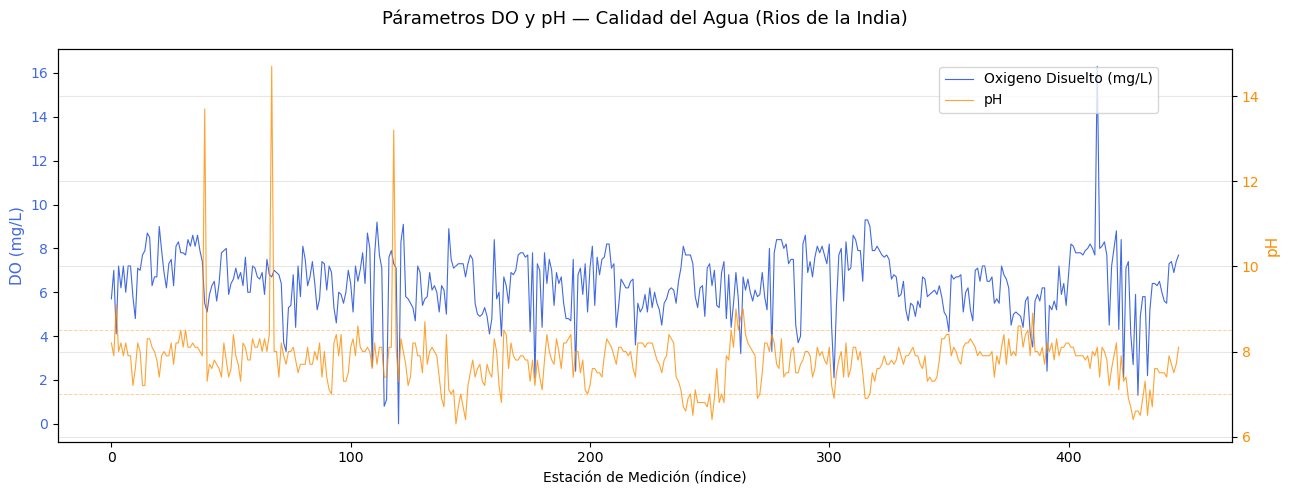

In [49]:
# ── Grafica 1: Oxigeno Disuelto (DO) y pH ────────────────────────────────────
# Dos ejes Y porque las escalas son distintas
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(range(tam), do_param, color='royalblue', lw=0.8, label='Oxigeno Disuelto (mg/L)')
ax1.set_ylabel('DO (mg/L)', color='royalblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='royalblue')

ax2 = ax1.twinx()
ax2.plot(range(tam), ph_param, color='darkorange', lw=0.8, alpha=0.8, label='pH')
ax2.set_ylabel('pH', color='darkorange', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkorange')
# Limites OMS de pH para agua potable: 7.0 a 8.5
ax2.axhline(7.0, color='darkorange', ls='--', alpha=0.4, lw=0.7)
ax2.axhline(8.5, color='darkorange', ls='--', alpha=0.4, lw=0.7)

fig.suptitle('Párametros DO y pH — Calidad del Agua (Rios de la India)', fontsize=13)
ax1.set_xlabel('Estación de Medición (índice)', fontsize=10)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

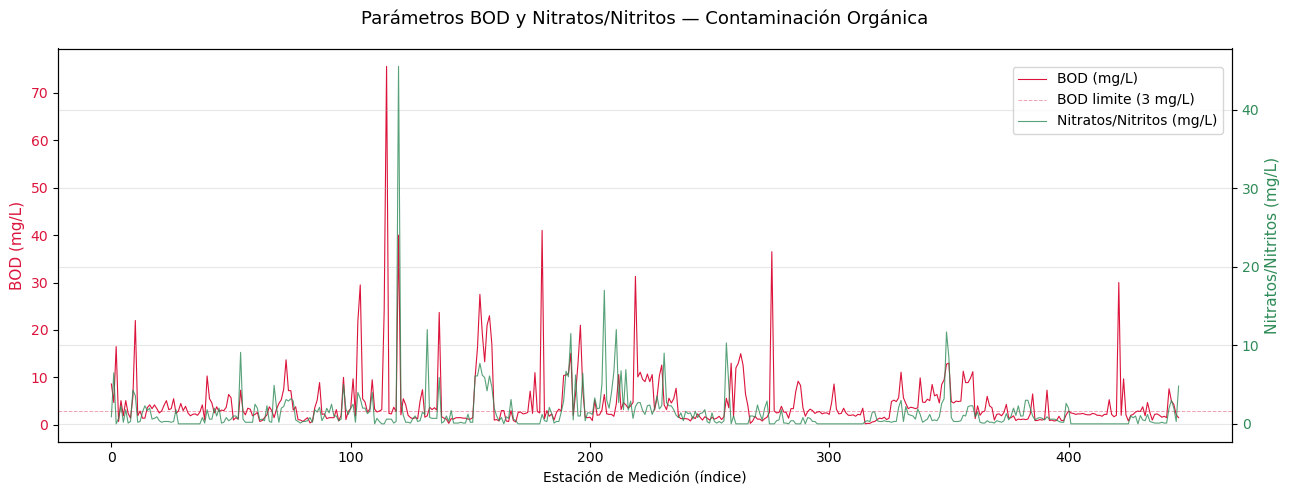

In [50]:
# ── Grafica 2: BOD y Nitratos/Nitritos ──────────────────────────────────────
# Ambos parametros reflejan contaminacion organica y agricola
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(range(tam), bod_param, color='crimson', lw=0.8, label='BOD (mg/L)')
ax1.set_ylabel('BOD (mg/L)', color='crimson', fontsize=11)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.axhline(3, color='crimson', ls='--', alpha=0.4, lw=0.7, label='BOD limite (3 mg/L)')

ax2 = ax1.twinx()
ax2.plot(range(tam), nn_param, color='seagreen', lw=0.8, alpha=0.8, label='Nitratos/Nitritos (mg/L)')
ax2.set_ylabel('Nitratos/Nitritos (mg/L)', color='seagreen', fontsize=11)
ax2.tick_params(axis='y', labelcolor='seagreen')

fig.suptitle('Parámetros BOD y Nitratos/Nitritos — Contaminación Orgánica', fontsize=13)
ax1.set_xlabel('Estación de Medición (índice)', fontsize=10)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.88))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

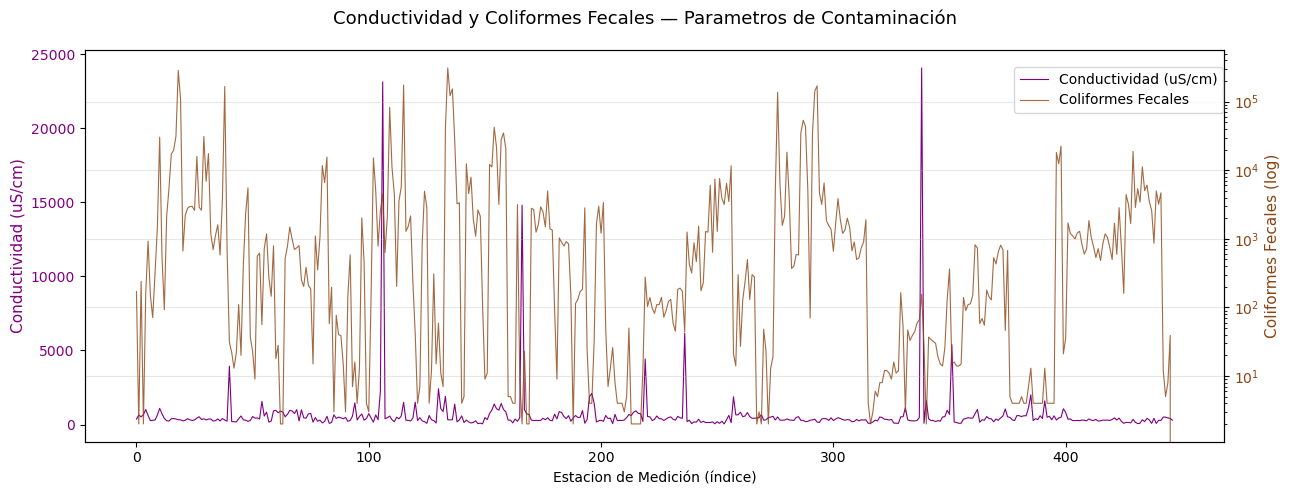

In [45]:
# ── Grafica 3: Conductividad y Coliformes Fecales ───────────────────────────
# Escala logaritmica en FC por la presencia de valores extremos (outliers)
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(range(tam), cond_param, color='purple', lw=0.8, label='Conductividad (uS/cm)')
ax1.set_ylabel('Conductividad (uS/cm)', color='purple', fontsize=11)
ax1.tick_params(axis='y', labelcolor='purple')

ax2 = ax1.twinx()
ax2.plot(range(tam), fc_param, color='saddlebrown', lw=0.8, alpha=0.8, label='Coliformes Fecales')
ax2.set_ylabel('Coliformes Fecales (log)', color='saddlebrown', fontsize=11)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='saddlebrown')

fig.suptitle('Conductividad y Coliformes Fecales — Parametros de Contaminación', fontsize=13)
ax1.set_xlabel('Estacion de Medición (índice)', fontsize=10)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.88))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

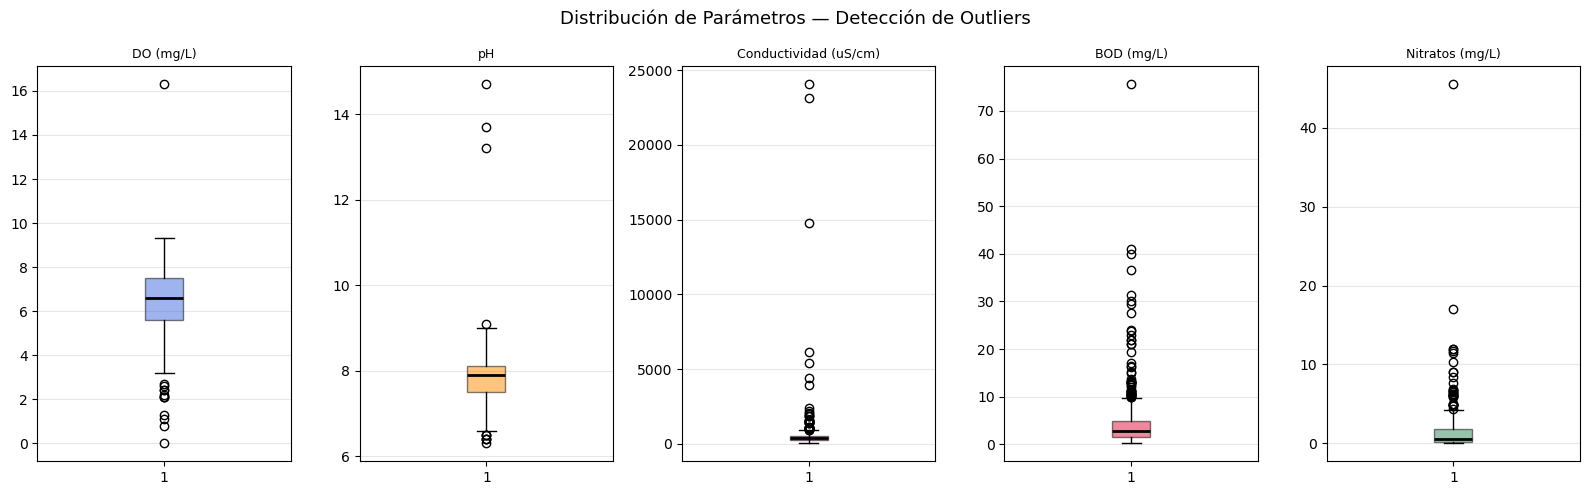

In [51]:
# ── Grafica 4: Boxplots para deteccion de outliers ──────────────────────────
df01_pd = df01.select('DO','pH','CONDUCTIVITY','BOD','NITRATE_N_NITRITE_N').toPandas()

fig, axes = plt.subplots(1, 5, figsize=(16, 5))
colores  = ['royalblue','darkorange','purple','crimson','seagreen']
nombres  = ['DO (mg/L)','pH','Conductividad (uS/cm)','BOD (mg/L)','Nitratos (mg/L)']

for i, (col, color, nom) in enumerate(zip(df01_pd.columns, colores, nombres)):
    axes[i].boxplot(df01_pd[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.5),
                   medianprops=dict(color='black', lw=2))
    axes[i].set_title(nom, fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Parámetros — Detección de Outliers', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Construcción del Índice de Calidad del Agua (WQI)

Cada parámetro se transforma en un **puntaje de calidad** (0 / 40 / 60 / 80 / 100) según rangos de la referencia bibliográfica, y luego se pondera.

| Rango WQI | Categoría |
|---|---|
| [0, 25) | Excelente — agua dulce |
| [25, 50) | Buena — agua moderada |
| [50, 75) | Baja — agua dura |
| [75, 100) | Muy Baja — agua muy dura |
| ≥ 100 | Inadecuada — agua residual |

In [56]:
# ── Puntajes de calidad por parametro (qr = quality rating) ──────────────────
# Cada funcion 'when' asigna 0/40/60/80/100 segun el rango del parametro

# qrPH: pH optimo 7.0 a 8.5
df02 = df01.withColumn('qrPH',
    F.when((df01.pH >= 7.0) & (df01.pH <= 8.5), 100)
     .when(((df01.pH >= 6.8) & (df01.pH < 7.0)) | ((df01.pH > 8.5) & (df01.pH < 8.6)), 80)
     .when(((df01.pH >= 6.7) & (df01.pH < 6.8)) | ((df01.pH >= 8.6) & (df01.pH < 8.8)), 60)
     .when(((df01.pH >= 6.5) & (df01.pH < 6.7)) | ((df01.pH >= 8.8) & (df01.pH < 9.0)), 40)
     .otherwise(0))

# qrDO: mayor DO = mayor calidad (agua bien oxigenada)
df02 = df02.withColumn('qrDO',
    F.when(df01.DO >= 6.0, 100)
     .when((df01.DO >= 5.1) & (df01.DO < 6.0), 80)
     .when((df01.DO >= 4.1) & (df01.DO < 5.1), 60)
     .when((df01.DO >= 3.0) & (df01.DO <= 4.0), 40)
     .otherwise(0))

# qrCOND: menor conductividad = agua más pura
df02 = df02.withColumn('qrCOND',
    F.when((df01.CONDUCTIVITY >= 0) & (df01.CONDUCTIVITY <= 75), 100)
     .when((df01.CONDUCTIVITY > 75) & (df01.CONDUCTIVITY <= 150), 80)
     .when((df01.CONDUCTIVITY > 150) & (df01.CONDUCTIVITY <= 225), 60)
     .when((df01.CONDUCTIVITY > 225) & (df01.CONDUCTIVITY <= 300), 40)
     .otherwise(0))

# qrBOD: menor BOD = menos materia orgánica = mejor calidad
df02 = df02.withColumn('qrBOD',
    F.when((df01.BOD >= 0) & (df01.BOD < 3), 100)
     .when((df01.BOD >= 3) & (df01.BOD < 6), 80)
     .when((df01.BOD >= 6) & (df01.BOD < 80), 60)
     .when((df01.BOD >= 80) & (df01.BOD < 125), 40)
     .otherwise(0))

# qrNN: menor nitratos/nitritos = mejor calidad
df02 = df02.withColumn('qrNN',
    F.when((df01.NITRATE_N_NITRITE_N >= 0) & (df01.NITRATE_N_NITRITE_N < 20), 100)
     .when((df01.NITRATE_N_NITRITE_N >= 20) & (df01.NITRATE_N_NITRITE_N < 50), 80)
     .when((df01.NITRATE_N_NITRITE_N >= 50) & (df01.NITRATE_N_NITRITE_N < 100), 60)
     .when((df01.NITRATE_N_NITRITE_N >= 100) & (df01.NITRATE_N_NITRITE_N < 200), 40)
     .otherwise(0))

# qrFecal: menor concentración bacteriana = mejor calidad
df02 = df02.withColumn('qrFecal',
    F.when((df01.FECAL_COLIFORM >= 0) & (df01.FECAL_COLIFORM < 5), 100)
     .when((df01.FECAL_COLIFORM >= 5) & (df01.FECAL_COLIFORM < 50), 80)
     .when((df01.FECAL_COLIFORM >= 50) & (df01.FECAL_COLIFORM < 500), 60)
     .when((df01.FECAL_COLIFORM >= 500) & (df01.FECAL_COLIFORM < 1000), 40)
     .otherwise(0))

print('Puntajes de calidad calculados:')
df02.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal').limit(10).toPandas()

Puntajes de calidad calculados:


,qrPH,qrDO,qrCOND,qrBOD,qrNN,qrFecal
0,100,100,0,80,100,100
1,100,100,40,80,100,60
2,100,80,0,80,100,60
3,100,80,0,80,100,60
4,100,80,40,80,100,80
5,100,60,0,60,100,60
6,100,80,0,60,100,60
7,100,80,0,80,100,60
8,100,80,0,80,100,60
9,100,100,60,100,100,80


In [59]:
# Se muestra el total de columnas
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

In [58]:
# ── Puntajes ponderados (w = weighted) ───────────────────────────────────────
# Los pesos provienen de la referencia bibliografica (InTech) y suman 0.998 ~1.0
# DO y FC tienen mayor peso (28.1% c/u) por ser los mas determinantes

df03 = df02.withColumn('wpH',    F.round(df02.qrPH    * 0.165, 3))  # 16.5%
df03 = df03.withColumn('wDO',    F.round(df03.qrDO    * 0.281, 3))  # 28.1%
df03 = df03.withColumn('wCOND',  F.round(df03.qrCOND  * 0.234, 3))  # 23.4%
df03 = df03.withColumn('wBOD',   F.round(df03.qrBOD   * 0.009, 3))  #  0.9%
df03 = df03.withColumn('wNN',    F.round(df03.qrNN    * 0.028, 3))  #  2.8%
df03 = df03.withColumn('wFecal', F.round(df03.qrFecal * 0.281, 3))  # 28.1%

print(f'Suma de pesos: {0.165+0.281+0.234+0.009+0.028+0.281:.3f}')
df03.select('wpH','wDO','wCOND','wBOD','wNN','wFecal').limit(10).toPandas()

Suma de pesos: 0.998


,wpH,wDO,wCOND,wBOD,wNN,wFecal
0,16.5,28.10,0.00,0.72,2.8,28.10
1,16.5,28.10,9.36,0.72,2.8,16.86
2,16.5,22.48,0.00,0.72,2.8,16.86
3,16.5,22.48,0.00,0.72,2.8,16.86
4,16.5,22.48,9.36,0.72,2.8,22.48
5,16.5,16.86,0.00,0.54,2.8,16.86
6,16.5,22.48,0.00,0.54,2.8,16.86
7,16.5,22.48,0.00,0.72,2.8,16.86
8,16.5,22.48,0.00,0.72,2.8,16.86
9,16.5,28.10,14.04,0.90,2.8,22.48


In [60]:
# Se muestra el total de columnas
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

In [62]:
# ── Calculo del WQI (suma ponderada de todos los puntajes) ───────────────────
df04 = df03.withColumn(
    'WQI',
    F.round(df03.wpH + df03.wDO + df03.wCOND + df03.wBOD + df03.wNN + df03.wFecal, 3)
)

print('WQI calculado (muestra):')
# df04.select('LOCATIONS','STATE','WQI').show(10, truncate=40)
df04.select('LOCATIONS','STATE','WQI').limit(10).toPandas()

WQI calculado (muestra):


,LOCATIONS,STATE,WQI
0,"GODAVARI AT JAYAKWADI DAM, AURNAGABAD,MAHARASHTRA",MAHARASHTRA,76.22
1,GODAVARI RIVER NEAR SOMESHWAR TEMPLE.,MAHARASHTRA,74.34
2,GODAVARI RIVER AT SAIKHEDA.,MAHARASHTRA,59.36
3,"GODAVARI RIVER AT HANUMAN GHAT, NASHIK CITY.",MAHARASHTRA,59.36
4,GODAVARI RIVER AT NANDUR- MADMESHWAR DAM.,MAHARASHTRA,74.34
5,GODAVARI RIVER AT KAPILA- GODAVARI CONFLUENCE ...,MAHARASHTRA,53.56
6,GODAVARI RIVER NEAR TAPOVAN.,MAHARASHTRA,59.18
7,"GODAVARI AT PANCHAVATI AT RAMKUND,MAHARASHTRA",MAHARASHTRA,59.36
8,"GODAVARI AT NASIK D/S, MAHARASHTRA",MAHARASHTRA,59.36
9,"GODAVARI AT U/S OF GANGAPUR DAM,NASIK,MAHARASHTRA",MAHARASHTRA,84.82


In [63]:
# ── Etiqueta de calidad segun rango WQI ──────────────────────────────────────
df05 = df04.withColumn('CALIDAD',
    F.when((df04.WQI >= 0)  & (df04.WQI < 25),  'Excelente')
     .when((df04.WQI >= 25) & (df04.WQI < 50),  'Buena')
     .when((df04.WQI >= 50) & (df04.WQI < 75),  'Baja')
     .when((df04.WQI >= 75) & (df04.WQI < 100), 'Muy_Baja')
     .otherwise('Inadecuada'))

print('Etiquetas de calidad asignadas:')
# df05.select('STATE','WQI','CALIDAD').show(10)
df05.select('STATE','WQI','CALIDAD').limit(10).toPandas()

Etiquetas de calidad asignadas:


,STATE,WQI,CALIDAD
0,MAHARASHTRA,76.22,Muy_Baja
1,MAHARASHTRA,74.34,Baja
2,MAHARASHTRA,59.36,Baja
3,MAHARASHTRA,59.36,Baja
4,MAHARASHTRA,74.34,Baja
5,MAHARASHTRA,53.56,Baja
6,MAHARASHTRA,59.18,Baja
7,MAHARASHTRA,59.36,Baja
8,MAHARASHTRA,59.36,Baja
9,MAHARASHTRA,84.82,Muy_Baja


### Análisis de Distribución de la Calidad del Agua

Distribución de categorias de calidad:
+---------+--------+
|  CALIDAD|Cantidad|
+---------+--------+
|     Baja|     271|
|    Buena|      95|
| Muy_Baja|      70|
|Excelente|      11|
+---------+--------+



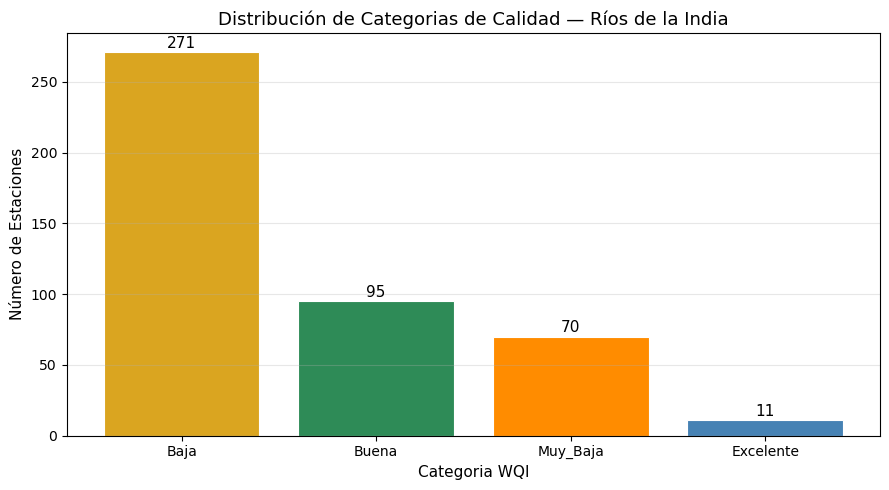

In [66]:
# ── Distribucion de categorias de calidad ────────────────────────────────────
dist = (df05.groupBy('CALIDAD')
        .count()
        .withColumnRenamed('count','Cantidad')
        .orderBy('Cantidad', ascending=False))

print('Distribución de categorias de calidad:')
dist.show()

# ── Grafica de barras ─────────────────────────────────────────────────────────
dist_pd = dist.toPandas()
colores_cat = {'Excelente':'steelblue','Buena':'seagreen',
               'Baja':'goldenrod','Muy_Baja':'darkorange','Inadecuada':'crimson'}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dist_pd['CALIDAD'], dist_pd['Cantidad'],
              color=[colores_cat.get(c,'gray') for c in dist_pd['CALIDAD']],
              edgecolor='white', lw=0.8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            str(int(b.get_height())), ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de Categorias de Calidad — Ríos de la India', fontsize=13)
ax.set_xlabel('Categoria WQI', fontsize=11)
ax.set_ylabel('Número de Estaciones', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# ── WQI promedio por estado ───────────────────────────────────────────────────
wqi_estado = (df05.groupBy('STATE')
              .agg(F.round(F.mean('WQI'), 2).alias('WQI_MEDIO'),
                   F.count('WQI').alias('N_ESTACIONES'))
              .orderBy('WQI_MEDIO'))

print('WQI Medio por Estado (de mejor a peor calidad):')
wqi_estado.limit(20).toPandas()

WQI Medio por Estado (de mejor a peor calidad):


,STATE,WQI_MEDIO,N_ESTACIONES
0,PUNJAB,37.17,12
1,WEST BENGAL,52.12,13
2,UTTAR PRADESH,52.29,47
3,GOA,53.19,36
4,TAMILNADU,54.18,7
5,BIHAR,55.30,60
6,GUJARAT,57.00,8
7,KARNATAKA,62.11,47
8,ASSAM,64.54,22
9,ANDHRA PRADESH,65.62,34


## 8. Visualización Geoespacial — Mapa de la India

In [76]:
# ── Normalizacion de nombres de estados para el JOIN con shapefile ────────────
# El CSV usa MAYUSCULAS; el shapefile usa Title Case

# Correcccion del nombre Tamil Nadu (inconsistencia en el CSV original)
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

# Convertir todo a formato Title Case (primera letra mayuscula por palabra)
df06 = df06.withColumn('STATE', F.initcap('STATE'))

print('Estados normalizados:')
# df06.select('STATE').distinct().orderBy('STATE').show(30, truncate=False)
df06.select('STATE').distinct().orderBy('STATE').limit(30).toPandas()

Estados normalizados:


,STATE
0,Andhra Pradesh
1,Assam
2,Bihar
3,Goa
4,Gujarat
5,Himachal Pradesh
6,Karnataka
7,Kerala
8,Madhya Pradesh
9,Maharashtra


In [71]:
pwd

'/home/usuario01/bravos.js/proyecto_aguas'

In [ ]:
# ── Carga del shapefile de la India con GeoPandas ────────────────────────────
import geopandas as gpd

RUTA_MAPA = '/home/usuario01/bravos.js/proyecto_aguas/Indian_States/Indian_States.shp'

try:
    gpd01 = gpd.read_file(RUTA_MAPA)
    print(f'Shapefile cargado | {len(gpd01)} estados | CRS: {gpd01.crs}')
    print(f'Columnas: {list(gpd01.columns)}')
except FileNotFoundError:
    print(f'[ERROR] Shapefile no encontrado en: {RUTA_MAPA}')
    print('Archivo no encontrado')

Shapefile cargado | 36 estados | CRS: EPSG:4326
Columnas: ['st_nm', 'geometry']


In [78]:
# ── Homologacion de nombres entre shapefile y dataset ────────────────────────
gpd02 = gpd01.replace({
    'Andaman & Nicobar Island': 'Andaman Nicobar Island',
    'Dadara & Nagar Havelli'  : 'Dadara Nagar Havelli',
    'Daman & Diu'             : 'Daman Diu',
    'Jammu & Kashmir'         : 'Jammu Kashmir',
    'NCT of Delhi'            : 'Delhi'
})
gpd03 = gpd02.rename(columns={'st_nm': 'STATE'})

# ── JOIN: geodataframe + WQI medio por estado ─────────────────────────────────
# Se calcula el WQI promedio por estado para representarlo en el mapa
df06_estado = (df06.groupBy('STATE')
               .agg(F.round(F.mean('WQI'), 2).alias('WQI'))
               .toPandas())

dfMAP = pd.merge(gpd03, df06_estado, how='outer', on='STATE')

# Puntos representativos dentro de cada poligono (para etiquetas)
dfMAP['coords'] = dfMAP['geometry'].apply(
    lambda x: x.representative_point().coords[:] if x is not None else None
)
dfMAP['coords'] = [c[0] if c else (None, None) for c in dfMAP['coords']]
dfMAP = dfMAP.drop_duplicates(subset='STATE')

# Imputar WQI faltante con la mediana (estados sin datos en el CSV)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

print(f'Mapa preparado | {len(dfMAP)} estados')

Mapa preparado | 36 estados


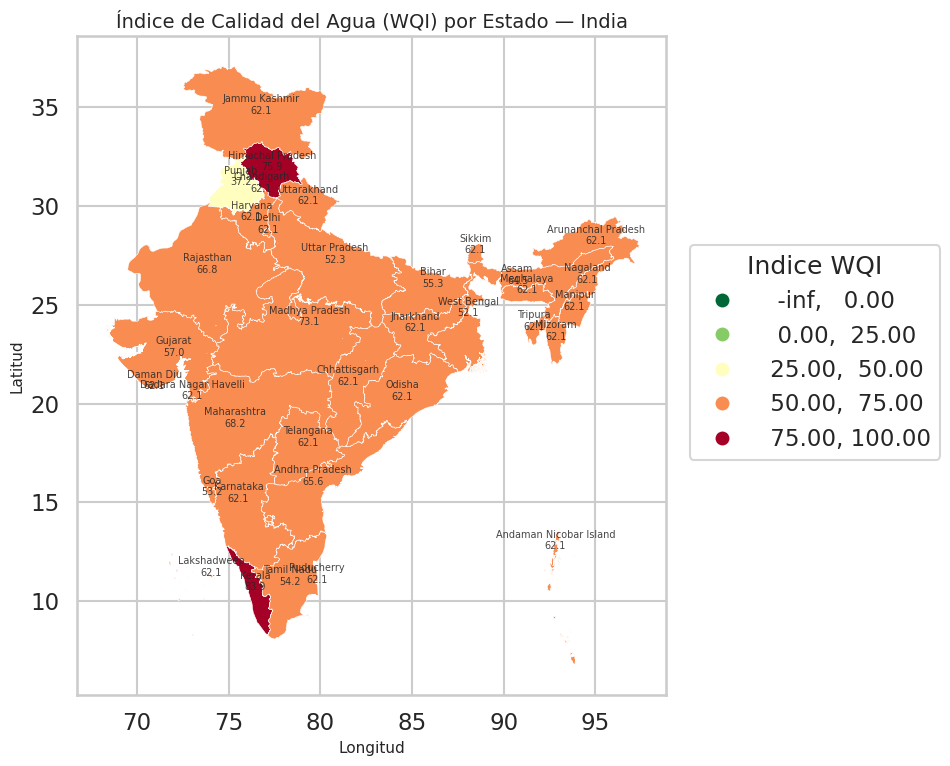

In [92]:
# ── Mapa coropletico del WQI por estado ──────────────────────────────────────
# Verde = mejor calidad, Rojo = peor calidad
sns.set_context('talk')
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(13, 8))
dfMAP.plot(
    column='WQI', cmap='RdYlGn_r', ax=ax,
    scheme='userdefined',
    classification_kwds={'bins': [0, 25, 50, 75, 100]},
    legend=True, linewidth=0.4, edgecolor='white',
    missing_kwds={'color': 'lightgrey'}
)

leg = ax.get_legend()
leg.set_title('Indice WQI')
leg.set_bbox_to_anchor((1.02, 0.7))

# Anotaciones con valor WQI en cada estado
textos = []
for _, row in dfMAP.iterrows():
    if row['coords'] and not pd.isna(row['WQI']):
        t = ax.annotate(f"{row['STATE']}\n{row['WQI']:.1f}",
                        xy=row['coords'], fontsize=7, ha='center', alpha=0.85)
        textos.append(t)

ax.set_title('Índice de Calidad del Agua (WQI) por Estado — India', fontsize=14)
ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud', fontsize=11)
plt.tight_layout()
plt.show()

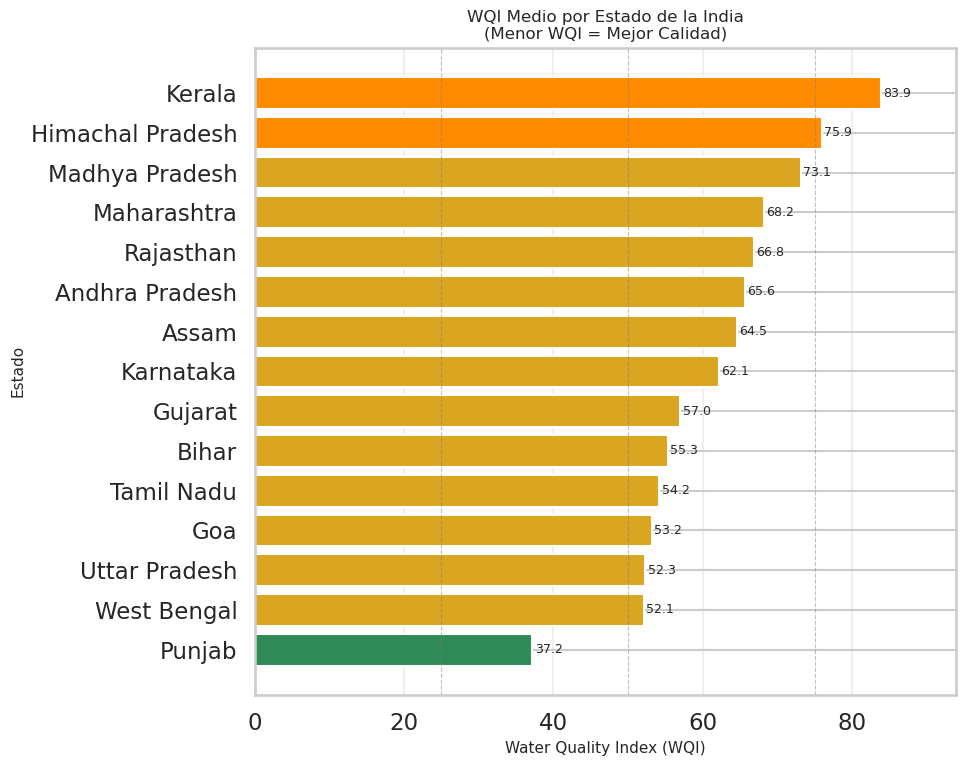

In [93]:
# ── Histograma horizontal: WQI medio por estado ──────────────────────────────
# Se agrega por estado (media) antes de graficar,
# para evitar multiples barras por estado y hacer la gráfica legible

wqi_pd = (df06.groupBy('STATE')
          .agg(F.round(F.mean('WQI'), 2).alias('WQI_MEDIO'))
          .orderBy('WQI_MEDIO')
          .toPandas())

def color_wqi(v):
    if v < 25:    return 'steelblue'
    elif v < 50:  return 'seagreen'
    elif v < 75:  return 'goldenrod'
    elif v < 100: return 'darkorange'
    else:          return 'crimson'

colores = [color_wqi(v) for v in wqi_pd['WQI_MEDIO']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(wqi_pd['STATE'], wqi_pd['WQI_MEDIO'], color=colores, edgecolor='white')
for b, v in zip(bars, wqi_pd['WQI_MEDIO']):
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9)

# Lineas verticales de referencia segun categorias WQI
for lim, etiq in [(25,'Excelente'),(50,'Buena'),(75,'Baja'),(100,'Muy Baja')]:
    ax.axvline(lim, color='gray', ls='--', alpha=0.5, lw=0.8)

ax.set_title('WQI Medio por Estado de la India\n(Menor WQI = Mejor Calidad)', fontsize=12)
ax.set_xlabel('Water Quality Index (WQI)', fontsize=11)
ax.set_ylabel('Estado', fontsize=11)
ax.set_xlim(0, wqi_pd['WQI_MEDIO'].max()+10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Modelo — Regresión Lineal con PySpark MLlib

Se usa LinearRegression de MLlib para predecir el WQI desde los puntajes de calidad.  
Este modelo corre de forma distribuida sobre el clúster Spark.

In [94]:
# ── Configuracion del pipeline de MLlib ──────────────────────────────────────
FEATURES = ['qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal']
TARGET   = 'WQI'

# VectorAssembler: combina los features en un unico vector columna
ensamblador = VectorAssembler(inputCols=FEATURES, outputCol='features')

# StandardScaler: estandariza (media=0, std=1) para estabilizar el gradiente
escalador = StandardScaler(inputCol='features', outputCol='features_scaled',
                           withMean=True, withStd=True)

# Regresion Lineal con regularizacion Ridge (regParam=0.01)
lr = LinearRegression(
    featuresCol='features_scaled',
    labelCol=TARGET,
    maxIter=200,
    regParam=0.01,       # Regularizacion L2 (Ridge): penaliza coeficientes grandes
    elasticNetParam=0.0  # 0.0 = Ridge puro
)

# Pipeline: encadena preprocesamiento + modelo en un solo objeto
pipeline = Pipeline(stages=[ensamblador, escalador, lr])

# Dataset sin nulos
df_ml = df06.select(FEATURES + [TARGET]).dropna()

# Division aleatoria 80% entrenamiento / 20% prueba (seed=42 para reproducibilidad)
df_train, df_test = df_ml.randomSplit([0.8, 0.2], seed=42)

print(f'Total  : {df_ml.count()} filas')
print(f'Train  : {df_train.count()} filas')
print(f'Test   : {df_test.count()} filas')

Total  : 447 filas
Train  : 383 filas
Test   : 64 filas


In [95]:
# ── Entrenamiento del modelo MLlib ────────────────────────────────────────────
modelo_mlllib = pipeline.fit(df_train)

# Predicciones sobre el conjunto de prueba
pred_mlllib = modelo_mlllib.transform(df_test)

print('Predicciones (muestra):')
pred_mlllib.select('WQI','prediction').show(10)

Predicciones (muestra):
+-----+------------------+
|  WQI|        prediction|
+-----+------------------+
|51.46| 51.46365626873556|
|40.98| 40.99028671650887|
|50.52| 50.52408213913222|
|32.42| 32.43570446607371|
|63.68| 63.67605780802196|
| 61.8|61.795449294748416|
|16.54| 16.57024597684856|
| 62.6| 62.59198664407107|
|41.76| 42.32905043616293|
|19.84|19.868514718233918|
+-----+------------------+
only showing top 10 rows



In [96]:
# ── Evaluacion del modelo MLlib ──────────────────────────────────────────────
evaluador = RegressionEvaluator(labelCol='WQI', predictionCol='prediction')

rmse_mlllib = evaluador.setMetricName('rmse').evaluate(pred_mlllib)
mae_mlllib  = evaluador.setMetricName('mae').evaluate(pred_mlllib)
r2_mlllib   = evaluador.setMetricName('r2').evaluate(pred_mlllib)

print('METRICAS — Regresion Lineal (MLlib)')
print(f'  RMSE : {rmse_mlllib:.4f}')
print(f'  MAE  : {mae_mlllib:.4f}')
print(f'  R2   : {r2_mlllib:.4f}')

# Coeficientes del modelo
lr_model = modelo_mlllib.stages[-1]
print('\nCoeficientes por feature:')
for feat, coef in zip(FEATURES, lr_model.coefficients):
    print(f'  {feat:<20} {coef:+.4f}')
print(f'  Intercepto:          {lr_model.intercept:.4f}')

METRICAS — Regresion Lineal (MLlib)
  RMSE : 0.0726
  MAE  : 0.0200
  R2   : 1.0000

Coeficientes por feature:
  qrPH                 +2.8758
  qrDO                 +5.8545
  qrCOND               +6.8449
  qrBOD                +0.1415
  qrNN                 +0.0000
  qrFecal              +10.4830
  Intercepto:          61.7345


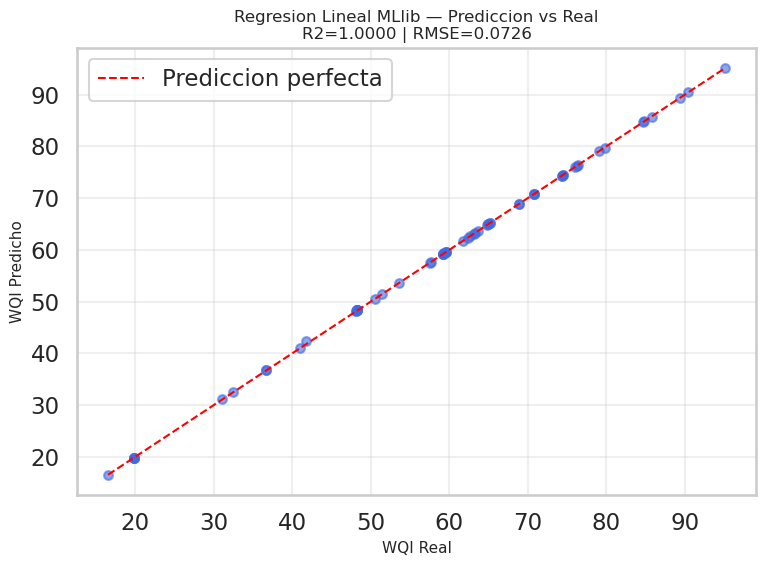

In [97]:
# ── Grafica: Predicción vs Real (MLlib) ──────────────────────────────────────
pred_pd = pred_mlllib.select('WQI','prediction').toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pred_pd['WQI'], pred_pd['prediction'], alpha=0.6, color='royalblue', s=40)
lim = [pred_pd.min().min(), pred_pd.max().max()]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prediccion perfecta')
ax.set_xlabel('WQI Real', fontsize=11)
ax.set_ylabel('WQI Predicho', fontsize=11)
ax.set_title(f'Regresion Lineal MLlib — Prediccion vs Real\nR2={r2_mlllib:.4f} | RMSE={rmse_mlllib:.4f}',
             fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Modelo — Red Neuronal con Keras (TensorFlow)

Se implementa una red neuronal densa (MLP) para predecir el WQI.  
Este modelo corre en el nodo driver y complementa el modelo distribuido de MLlib.

In [98]:
# ── Preparacion de datos para Keras (Pandas/NumPy) ───────────────────────────
dfcalidad  = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal').dropna()
dfPredecir = df06.select('WQI').dropna()

# Division entrenamiento 80% / prueba 20% con semilla para reproducibilidad
dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(), dfPredecir.toPandas(),
    test_size=0.2, random_state=42
)

print(f'Total          : {dfcalidad.count()}')
print(f'Entrenamiento  : X={dataTrain.shape}, y={predTrain.shape}')
print(f'Prueba         : X={dataTest.shape},  y={predTest.shape}')

Total          : 447
Entrenamiento  : X=(357, 6), y=(357, 1)
Prueba         : X=(90, 6),  y=(90, 1)


In [99]:
# ── Importacion de Keras / TensorFlow ────────────────────────────────────────
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# ── Arquitectura de la red neuronal ──────────────────────────────────────────
# Entrada: 6 puntajes de calidad por parametro
# Salida : 1 valor continuo (WQI predicho)
epochas = 300
lote    = 64

modelo01 = Sequential([
    Dense(256, input_dim=6, activation='relu'),  # Capa 1: 256 neuronas, activacion ReLU
    Dropout(0.2),                                 # Regularizacion: apaga 20% de neuronas
    Dense(256, activation='relu'),               # Capa 2: 256 neuronas
    Dropout(0.2),
    Dense(128, activation='relu'),               # Capa 3: 128 neuronas
    Dense(1,   activation='linear')             # Salida: regresion (valor continuo)
])

# Optimizador Adam + perdida MSE (Error Cuadratico Medio)
modelo01.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

modelo01.summary()

I0000 00:00:1779682616.842968  861593 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/envs/rapKernel_v4/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1779682617.939168  861593 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
# ── Early Stopping: para el entrenamiento si val_loss no mejora en 30 epocas ──
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

# ── Entrenamiento ─────────────────────────────────────────────────────────────
ejecutarK = modelo01.fit(
    dataTrain, predTrain,
    epochs=epochas,
    batch_size=lote,
    validation_split=0.15,  # 15% del train para validacion durante entrenamiento
    callbacks=[early_stop],
    verbose=1
)

print(f'\nEntrenamiento completado en {len(ejecutarK.history["loss"])} epocas')

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1551.2428 - mae: 31.4856 - val_loss: 529.8142 - val_mae: 21.7986
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 558.7577 - mae: 19.9533 - val_loss: 121.3104 - val_mae: 9.2321
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 233.2047 - mae: 12.1592 - val_loss: 436.4095 - val_mae: 19.0383
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 216.6786 - mae: 12.1575 - val_loss: 91.6626 - val_mae: 8.0068
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 99.4440 - mae: 7.7962 - val_loss: 27.2649 - val_mae: 4.2705
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 123.4987 - mae: 8.6243 - val_loss: 35.2303 - val_mae: 4.9608
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 85.0936 - mae: 7.3138 - val_loss: 116.0279 - val_mae: 9.8958
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 75.6357 - mae: 6.9700 - val_loss: 26.3697 - val_mae: 4.5709
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/s

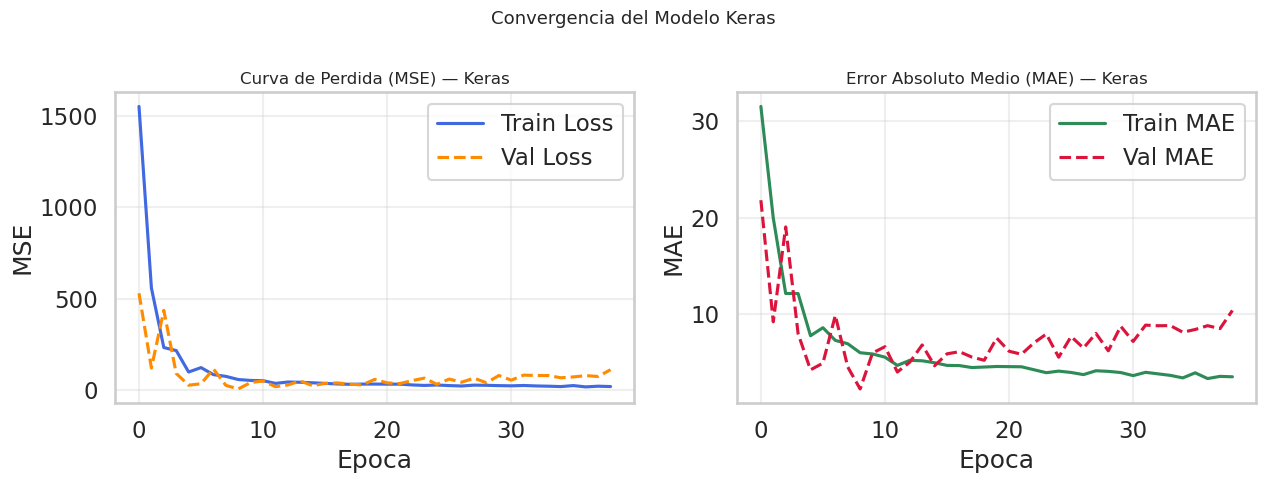

In [101]:
# ── Curvas de aprendizaje: Loss y MAE ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ejecutarK.history['loss'],     color='royalblue', label='Train Loss')
axes[0].plot(ejecutarK.history['val_loss'], color='darkorange', ls='--', label='Val Loss')
axes[0].set_title('Curva de Perdida (MSE) — Keras', fontsize=12)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ejecutarK.history['mae'],     color='seagreen', label='Train MAE')
axes[1].plot(ejecutarK.history['val_mae'], color='crimson', ls='--', label='Val MAE')
axes[1].set_title('Error Absoluto Medio (MAE) — Keras', fontsize=12)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Convergencia del Modelo Keras', fontsize=13)
plt.tight_layout()
plt.show()

In [102]:
# ── Evaluacion del modelo Keras sobre datos de prueba ────────────────────────
predModelo01_Train = modelo01.predict(dataTrain, verbose=0)
predModelo01_Test  = modelo01.predict(dataTest,  verbose=0)

# Metricas sobre el conjunto de PRUEBA (datos no vistos durante entrenamiento)
rmse_k = np.sqrt(mean_squared_error(predTest, predModelo01_Test))
mae_k  = mean_absolute_error(predTest, predModelo01_Test)
r2_k   = r2_score(predTest, predModelo01_Test)

print('METRICAS — Red Neuronal Keras (Test)')
print(f'  RMSE : {rmse_k:.4f}')
print(f'  MAE  : {mae_k:.4f}')
print(f'  R2   : {r2_k:.4f}')

METRICAS — Red Neuronal Keras (Test)
  RMSE : 4.2619
  MAE  : 3.0545
  R2   : 0.9187


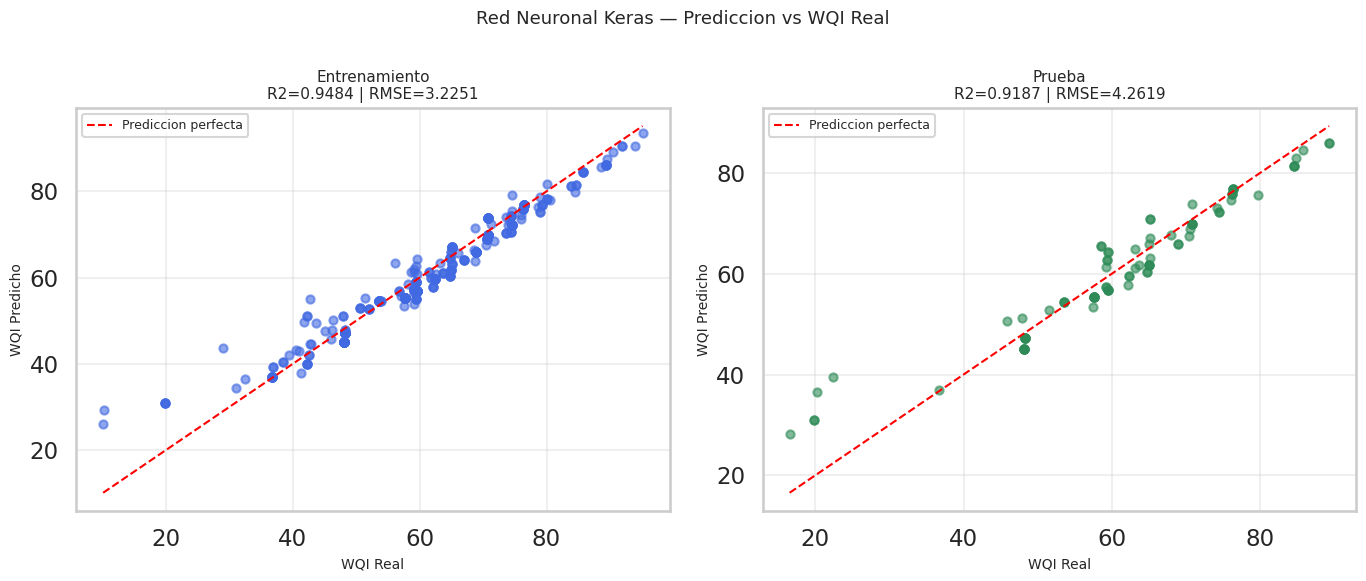

In [103]:
# ── Grafica: Prediccion vs Real — Entrenamiento y Prueba ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pares = [
    (predTrain.values.flatten(), predModelo01_Train.flatten(), 'Entrenamiento', 'royalblue'),
    (predTest.values.flatten(),  predModelo01_Test.flatten(),  'Prueba',        'seagreen')
]

for ax, (y_real, y_pred, titulo, color) in zip(axes, pares):
    ax.scatter(y_real, y_pred, alpha=0.6, color=color, s=35)
    lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Prediccion perfecta')
    r2  = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ax.set_xlabel('WQI Real', fontsize=10)
    ax.set_ylabel('WQI Predicho', fontsize=10)
    ax.set_title(f'{titulo}\nR2={r2:.4f} | RMSE={rmse:.4f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Red Neuronal Keras — Prediccion vs WQI Real', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Comparación de Modelos

                  Modelo   RMSE    MAE     R2                     Entorno
Regresión Lineal (MLlib) 0.0726 0.0200 1.0000 Distribuido (Spark Cluster)
    Red Neuronal (Keras) 4.2619 3.0545 0.9187   Driver local (TensorFlow)


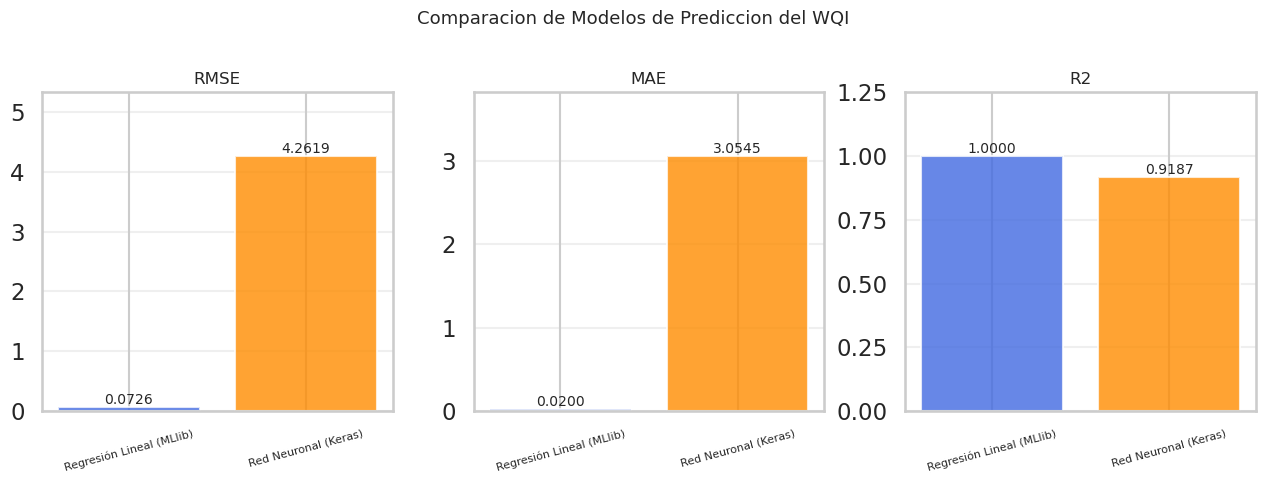

In [104]:
# ── Tabla comparativa de metricas ────────────────────────────────────────────
resumen = pd.DataFrame({
    'Modelo'  : ['Regresión Lineal (MLlib)', 'Red Neuronal (Keras)'],
    'RMSE'    : [round(rmse_mlllib, 4), round(rmse_k, 4)],
    'MAE'     : [round(mae_mlllib, 4),  round(mae_k, 4)],
    'R2'      : [round(r2_mlllib, 4),   round(r2_k, 4)],
    'Entorno' : ['Distribuido (Spark Cluster)', 'Driver local (TensorFlow)']
})
print(resumen.to_string(index=False))

# ── Grafica comparativa ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metricas = ['RMSE','MAE','R2']
colores  = ['royalblue','darkorange']

for i, metrica in enumerate(metricas):
    vals  = resumen[metrica].values
    bars  = axes[i].bar(resumen['Modelo'], vals, color=colores, alpha=0.8, edgecolor='white')
    for b, v in zip(bars, vals):
        axes[i].text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    axes[i].set_title(metrica, fontsize=12)
    axes[i].set_ylim(0, max(vals)*1.25)
    axes[i].tick_params(axis='x', rotation=15, labelsize=8)
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Comparacion de Modelos de Prediccion del WQI', fontsize=13)
plt.tight_layout()
plt.show()

In [105]:
# ── Cerrar la sesión de Spark y liberar recursos del clúster ──────────────────
sparkS.stop()

## 12. Conclusiones, Análisis y Observaciones


###  Análisis exploratorio
- La eliminación de registros incompletos permitió trabajar con datos consistentes, aunque también implicó una pérdida aproximada del 16 % de la información inicial.

- Las variables con mayor cantidad de valores faltantes fueron `FECAL_COLIFORM` y `CONDUCTIVITY`, lo que puede afectar el análisis microbiológico y fisicoquímico del agua.

- Algunas variables presentan alta dispersión y valores extremos, especialmente `CONDUCTIVITY`, `BOD` y `FECAL_COLIFORM`.

- La presencia de outliers sugiere que existen estaciones con condiciones de contaminación mucho más críticas que el promedio general.

- El pH se mantiene en rangos relativamente estables en la mayoría de observaciones, por lo que no parece ser el principal factor de deterioro del agua.

- El oxígeno disuelto presenta mayor variabilidad, lo cual es relevante porque valores bajos pueden indicar menor capacidad del agua para sostener vida acuática.

- Los picos altos de BOD pueden asociarse con contaminación orgánica o descargas de aguas residuales.

- Los valores extremos de coliformes fecales indican posibles problemas de contaminación microbiológica.

### Análisis de Outliers

- Los boxplots permitieron evidenciar la existencia de valores atípicos en varias variables. La conductividad presenta una distribución muy asimétrica, con algunos registros extremadamente altos frente al comportamiento general del conjunto de datos. Esto indica que no todas las estaciones tienen condiciones homogéneas y que existen puntos específicos con una contaminación elevada.

- El BOD también presenta outliers significativo. Aunque la mayoría de valores puede ubicarse en rangos moderados, los valores extremos muestran estaciones con condiciones mucho más deterioradas.

- Finalmente, en el caso de Coliformes Fecales, aunque no se incluyó directamente en el boxplot principal, su estadística descriptiva muestra una dispersión muy alta: la media es de aproximadamente 7.384, pero el máximo llega a 310.417. Esta diferencia muestra que la distribución está fuertemente sesgada por valores extremos.

### Interpretación del WQI

El Índice de Calidad del Agua, WQI, fue construido a partir de puntajes de calidad asignados a cada variable y ponderados según su importancia. Los pesos utilizados muestran que las variables más determinantes son:

- Oxígeno Disuelto (DO): 28,1 %
- Coliformes Fecales: 28,1 %
- Conductividad: 23,4 %
- pH: 16,5 %
- Nitratos/Nitritos: 2,8 %
- BOD: 0,9 %

La distribución de categorías muestra que la mayor parte de las estaciones se clasifica como Baja calidad, con 271 registros, equivalentes aproximadamente al 60,63 % del total. Luego aparece la categoría Buena, con 95 registros o 21,25 %. La categoría Muy Baja representa 70 registros, aproximadamente 15,66 %, mientras que solo 11 estaciones, equivalentes al 2,46 %, se clasifican como Excelente.

Por tanto, una conclusión importante es que el conjunto de datos no está dominado por agua de excelente o buena calidad, sino por estaciones con una calidad intermedia-baja. Esto sugiere que, aunque no todas las estaciones presentan condiciones críticas, sí existe una tendencia general hacia niveles de calidad que requieren monitoreo y posibles acciones de control.

El análisis del WQI promedio por estado muestra diferencias regionales relevantes. Punjab aparece como el estado con mejor calidad promedio, con un WQI medio de 37,17, ubicado dentro de la categoría “Buena”. En contraste, estados como Kerala, Himachal Pradesh y Madhya Pradesh presentan valores promedio más altos, lo cual indica peor calidad relativa del agua bajo la escala utilizada.

Sin embargo, es importante tener cuenta que el número de estaciones por estado no es uniforme. Por ejemplo, Maharashtra tiene 90 estaciones, Bihar tiene 60 y Uttar Pradesh y Karnataka tienen 47, mientras que Kerala solo tiene 2 estaciones. Por esta razón, el promedio de estados con pocas estaciones puede ser menos representativo y más sensible a valores extremos.

### Modelos Utilizados
- La Regresión Lineal superó claramente a la Red Neuronal en todas las métricas evaluadas. El mejor desempeño de la Regresión Lineal se debe a que el WQI tiene una estructura lineal y ponderada. La Red Neuronal es más flexible y compleja, pero esa complejidad no fue necesaria para este problema.

- Un modelo más complejo no siempre es mejor, especialmente cuando la variable objetivo se calcula mediante una fórmula simple. En este caso, la Regresión Lineal ofrece mejor balance entre precisión, interpretabilidad y eficiencia computacional, mientras que la Red Neuronal podría ser más útil si se trabajara con relaciones no lineales, más variables o un volumen mucho mayor de datos. Adicionalmente, la Regresión Lineal utilizanfo MLlib ofrece una solución escalable y distribuida, que ayuda a manejar grandes volúmenes de datos en el clúster Spark.

### Conclusiones Generales

- El análisis evidencia que la calidad del agua en las estaciones evaluadas presenta una situación heterogénea, pero con predominio de niveles de calidad clasificados como Baja. Los principales factores asociados al deterioro del índice son la presencia de coliformes fecales, la conductividad y el oxígeno disuelto, variables que tienen el mayor peso dentro del cálculo del WQI.
  
- El uso de PySpark y hdfs permitió procesar, limpiar y transformar los datos de manera estructurada, además de construir un pipeline de machine learning distribuido. La Regresión Lineal de MLlib demostró ser el modelo más adecuado para este problema, no solo por sus métricas casi perfectas, sino porque la naturaleza del WQI es lineal y ponderada.

- La red neuronal también logró un desempeño aceptable, pero no superó al modelo lineal. Esto demuestra que modelos más complejos no siempre producen mejores resultados, especialmente cuando la variable objetivo tiene una estructura matemática simple y explicable.